# Aim of Notebook: BTS Character.AI Corpus Construction

This notebook constructs a structured corpus of Character.AI bots representing members of the K-pop group BTS using the Nomic Atlas dataset.

The notebook proceeds in two stages:

1. **Dataset Loading and Quality Assessment**
   - Authenticates with the Nomic API and loads the Character.AI dataset from Nomic Atlas.
   - Examines the dataset metadata.
   - Assesses data quality by identifying and summarizing missing values across variables.

<br>    

2. **Corpus Construction**
   - Filters the dataset to retain only English-language bots representing BTS members.
   - Exports the resulting corpus as eight CSV files: one combined corpus containing all BTS bots and seven member-specific corpora (one for each BTS member). These files serve as the input for the subsequent data cleaning and preprocessing.

 # Table of Contents  


1. [Setting Up Notebook Environment](#1)

2. [Setting Up Nomic Atlas Character.AI Dataset](#2)

3. [General Overview of Character.AI Dataset on Nomic](#3)

   3.1 [Metadata](#3.1)

   3.2 [Database Size and Structure](#3.2)

   3.3 [Random Sample Dataset Records](#3.3)

   3.4 [Percentage of Missing Values in Dataset](#3.4)


4. [BTS Character Bots Corpus](#4)

   4.1 [Filtering BTS Bots](#4.1)

   4.2 [Saving BTS Bots](#4.2)

   4.3 [Number of BTS Bots](#4.3)

   4.4 [Sample Records Generated Randomly of BTS Bots](#4.4)



<a id="1"></a>

# 1. Setting up Notebook Environment 

This section configures the Jupyter environment for corpus construction by importing core data science libraries (`pandas`, `numpy`, `plotly` and HTML/display utilities), and sets up the project directory paths. 


Together, these configurations support reproducible and iterative development, particularly when working with reusable functions stored in the **`scripts/`** directory.


In [1]:
# core libraries
import os
import sys
import json
import numpy as np
import pandas as pd

#path
from pathlib import Path
import sys
from datetime import datetime


# visualization
import plotly.express as px
import plotly.graph_objects as go
#also pip install kaliedo if not there 
#for saving plotly graphs in different formats

# notebook display
from IPython.display import display, HTML, Markdown
import html

#project paths
PROJECT_ROOT = Path.cwd().parent
SCRIPTS_PATH = PROJECT_ROOT / "scripts"

REPORTS_PATH = PROJECT_ROOT / "reports"
BOTS_REPORTS_PATH = REPORTS_PATH / "bots_reports"

BOTS_REPORTS_PATH.mkdir(parents=True, exist_ok=True)


# Remove previously loaded conflicting package (Jupyter safety)
if "scripts" in sys.modules:
    del sys.modules["scripts"]

# Add project root to Python path
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Scripts folder exists:", SCRIPTS_PATH.exists())
print("Report folder exists:", REPORTS_PATH.exists())




D:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root: E:\Jupyter_Programs\DH_Thesis
Scripts folder exists: True
Report folder exists: True


<a id="2"></a>


# 2. Setting Up Nomic Atlas's Character.AI Dataset

This section connects the notebook to Nomic Atlas and loads the Character.AI dataset.

It does the following: 
- Adds the project root to the Python path so local modules in `scripts/` can be imported
- Imports and executes the `login_nomic()` function to authenticate with Nomic Atlas
- Loads the dataset using `load_nomic_dataset()` from `scripts/cai_nomic.py`

If successful:
- `df` contains the dataset as a pandas DataFrame
- `meta` contains dataset metadata (schema, source info, or annotations)

If loading fails:
- `df` is set to `None`
- an error message is printed for debugging


In [2]:

# Data path
CAI_RAW_PATH = PROJECT_ROOT / "data" / "raw"
CAI_RAW_PATH.mkdir(parents=True, exist_ok=True)

CAI_DATA_PATH = CAI_RAW_PATH / "cai_nomic.csv"


# Import scripts
from scripts.nomic_login import login_nomic
from scripts.cai_nomic import load_nomic_dataset

print("Dataset login scripts imported successfully")


# ============================================================
# Load dataset
# ============================================================

try:
    # Attempt Nomic Atlas loading
    login_nomic()

    df, meta = load_nomic_dataset()

    print("Dataset loaded successfully from Nomic Atlas")


    # Save raw dataset only if it does not already exist

    if CAI_DATA_PATH.exists():

        print(f"Raw dataset already exists: {CAI_DATA_PATH}")

    else:

        df.to_csv(
            CAI_DATA_PATH,
            index=False
        )

        print(f"Raw dataset saved: {CAI_DATA_PATH}")



except Exception as e:

    print("Nomic Atlas loading failed:. This could be possible if API key has expired.")
    print(e)


    # Fallback: load local raw dataset

    if CAI_DATA_PATH.exists():

        print("Loading local raw dataset...")

        df = pd.read_csv(
            CAI_DATA_PATH
        )

        print(
            f"Dataset loaded from local copy: {CAI_DATA_PATH}"
        )

    else:

        raise FileNotFoundError(
            """
    Dataset unavailable.
    
    Nomic Atlas loading failed and no local raw copy was found.
    
    Please contact the author of this project (Chahna Ahuja) to obtain the raw Character.AI dataset
    before running this notebook.
    """
        )

Dataset login scripts imported successfully
Login Successful!


2026-07-14 16:29:26.618 | INFO     | nomic.dataset:__init__:817 - Loading existing dataset `auth0thread765/all-cai-characters-`.
2026-07-14 16:29:28.144 | WARNING  | nomic.data_operations:df:1173 - Converting to pandas dataframe. This may materialize a large amount of data into memory.
2026-07-14 16:29:28.145 | INFO     | nomic.data_operations:_download_data:1142 - Downloading data
100%|████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 6513.44it/s]
2026-07-14 16:29:30.301 | INFO     | nomic.data_operations:_load_data:1069 - Loading data
100%|██████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 19.04it/s]


Dataset loaded successfully from Nomic Atlas
Raw dataset already exists: E:\Jupyter_Programs\DH_Thesis\data\raw\cai_nomic.csv


<a id="3"></a>


# 3. General Overview of Character.ai Dataset on Nomic

This section verifies the Nomic metadata for the dataset, displays the dataset size and structure, shows sample records and assesses the dataset quality by calculating the percentage of missing value in each field of the dataset.

<a id="3.1"></a>


## 3.1 Metadata

Overview of Nomic Atlas Charactr.ai metadata including project details, access permissions, fields, and embedding configuration from Nomic Atlas.

In [3]:
METADATA_REPORT_PATH = BOTS_REPORTS_PATH / "01_cai_dataset_metadata.md"


#printing important metadata 
def save_metadata_report(meta, output_path):

    atlas_section = ""

    for idx in meta.get("atlas_indices", []):
        atlas_section += f"""
### Atlas Index

- **Index Name:** {idx.get('index_name')}
- **Indexed Field:** {idx.get('indexed_field')}
- **Atoms:** {", ".join(idx.get('atoms', []))}
- **Colorable Fields:** {", ".join(idx.get('colorable_fields', []))}
"""

        for embed in idx.get("embedders", []):
            atlas_section += f"""
#### Embedding Configuration

- **Model:** {embed.get('model_name')}
- **Ready:** {embed.get('ready')}
"""

    permissions = meta.get("permissions", {})
    analyst_info = meta.get("analyst_info", {})

    report = f"""# Character.AI BTS Corpus Metadata Report

**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

---

## Dataset Information

| Field | Value |
|---|---|
| Project Name | {meta.get('project_name')} |
| Project ID | {meta.get('id')} |
| Creator / Owner | {meta.get('creator_nickname')} |
| Creator ID | {meta.get('creator')} |
| Organization | {meta.get('organization_name')} |
| Public Dataset | {meta.get('is_public')} |
| Privacy Level | {meta.get('privacy')} |
| Created Timestamp | {meta.get('created_timestamp')} |
| Total Data Points | {meta.get('total_datums_in_project'):,} |

---

## Metadata Fields

| Field | Value |
|---|---|
| Project Fields | {", ".join(meta.get('project_fields', []))} |
| Unique ID Field | {meta.get('unique_id_field')} |
| Modality | {meta.get('modality')} |

---

## Access and Permissions

| Permission | Status |
|---|---|
| Access Role | {meta.get('access_role')} |
| Read Metadata | {permissions.get('dataset:metadata:read')} |
| Read Data | {permissions.get('dataset:data:read')} |
| Write/Edit Data | {permissions.get('dataset:data:write')} |

---

## Nomic Atlas Embedding Configuration

{atlas_section}

---

## Additional Information

| Field | Value |
|---|---|
| Dataset Slug | {meta.get('slug')} |
| Connector | {meta.get('connector_name')} |
| AI Subprocessor | {analyst_info.get('ai_subprocessor')} |

"""

if METADATA_REPORT_PATH.exists():

    print(f"Metadata report already exists: {METADATA_REPORT_PATH}")

else:

    save_metadata_report(
        meta,
        METADATA_REPORT_PATH
    )


# Display existing/generated report
if METADATA_REPORT_PATH.exists():

    display(Markdown(
        METADATA_REPORT_PATH.read_text(encoding="utf-8")
    ))

Metadata report already exists: E:\Jupyter_Programs\DH_Thesis\reports\bots_reports\01_cai_dataset_metadata.md


# Character.AI BTS Corpus Metadata Report

**Generated:** 2026-07-14 15:07:36

---

## Dataset Information

| Field | Value |
|---|---|
| Project Name | All C.AI Characters  |
| Project ID | 153aa02c-6b4b-4723-858c-c3c8622d31fc |
| Creator / Owner | auth0.thread765 |
| Creator ID | auth0|672181d2ac71294fbcfdb387 |
| Organization | auth0.thread765 |
| Public Dataset | True |
| Privacy Level | public |
| Created Timestamp | 2024-10-31T00:08:09.155322Z |
| Total Data Points | 783,978 |

---

## Metadata Fields

| Field | Value |
|---|---|
| Project Fields | avatar, name, description, expertise, personality_question, personality_answer, greeting, upvotes, interactions, categories, creator, language, participant, external_id, row_number |
| Unique ID Field | row_number |
| Modality | text |

---

## Access and Permissions

| Permission | Status |
|---|---|
| Access Role | EXTERNAL |
| Read Metadata | True |
| Read Data | True |
| Write/Edit Data | False |

---

## Nomic Atlas Embedding Configuration


### Atlas Index

- **Index Name:** All C.AI Characters 
- **Indexed Field:** description
- **Atoms:** charchunk, document
- **Colorable Fields:** avatar, name, expertise, personality_question, personality_answer, greeting, upvotes, interactions, categories, creator, language, participant, external_id

#### Embedding Configuration

- **Model:** nomic-embed-text-v1.5
- **Ready:** True


---

## Additional Information

| Field | Value |
|---|---|
| Dataset Slug | all-cai-characters- |
| Connector | None |
| AI Subprocessor | openai |



<a id="3.2"></a>


## 3.2 Database Size and Structure
Summary of dataset dimensions, column types, and structural layout to understand overall Nomic Atlas corpus composition.

In [4]:
# 3.2 Dataset Size and Column Structure


# Report path
DATASET_STRUCTURE_REPORT = BOTS_REPORTS_PATH / "02_cai_dataset_structure.md"

# Save dataset structure report

def save_dataset_structure_report(df, output_path):

    total_rows, total_cols = df.shape

    cols_df = (
        df.dtypes
        .reset_index()
    )

    cols_df.columns = [
        "Column Name",
        "Data Type"
    ]

    columns_table = cols_df.to_markdown(
        index=False
    )

    report = f"""# Character.AI BTS Corpus Dataset Structure Report

**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

---

## Dataset Size

| Metric | Value |
|---|---:|
| Total Records | {total_rows:,} |
| Total Columns | {total_cols} |

---

## Column Schema

The following table provides an overview of the variables available in the Character.AI dataset and their corresponding data types.

{columns_table}


"""

    output_path.write_text(
        report,
        encoding="utf-8"
    )

    print(f"Dataset structure report saved to: {output_path}")




#report file

if DATASET_STRUCTURE_REPORT.exists():

    print(f"Report already exists: {DATASET_STRUCTURE_REPORT}")

else:

    save_dataset_structure_report(
        df,
        DATASET_STRUCTURE_REPORT
    )



# Display saved report
display(Markdown(
    DATASET_STRUCTURE_REPORT.read_text(encoding="utf-8")
))

Report already exists: E:\Jupyter_Programs\DH_Thesis\reports\bots_reports\02_cai_dataset_structure.md


# Character.AI BTS Corpus Dataset Structure Report

**Generated:** 2026-07-14 15:12:03

---

## Dataset Size

| Metric | Value |
|---|---:|
| Total Records | 783,978 |
| Total Columns | 15 |

---

## Column Schema

The following table provides an overview of the variables available in the Character.AI dataset and their corresponding data types.

| Column Name          | Data Type   |
|:---------------------|:------------|
| row_number           | str         |
| personality_question | category    |
| upvotes              | int32       |
| interactions         | int32       |
| categories           | category    |
| language             | category    |
| expertise            | str         |
| avatar               | str         |
| external_id          | str         |
| greeting             | str         |
| participant          | object      |
| personality_answer   | object      |
| creator              | object      |
| description          | str         |
| name                 | str         |




<a id="3.3"></a>


## 3.3 Random Sample Dataset Records

Display of randomly selected dataset entries to inspect structure, field consistency, and content quality.

In [5]:
display(HTML("<h3>3.3 Ten Sample Records Generated Randomly</h3>"))

sample_df = df.sample(10, random_state=42)

for _, row in sample_df.iterrows():

    display(HTML(
        "<div style='padding:10px; border:1px solid #ccc; border-radius:8px; margin-bottom:10px;'>"
        + "".join(
            f"<b>{html.escape(col.replace('_', ' ').title())}:</b> {html.escape(str(val))}<br>"
            for col, val in row.items()
        )
        + "</div>"
    ))

<a id="3.4"></a>


## 3.4 Percentage of Missing Values in Dataset

Column-wise analysis of missing data to identify sparsity patterns and assess feature reliability across the dataset.

C:\Users\chahn\AppData\Local\Temp\ipykernel_12688\4094458087.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_null.select_dtypes(include=["object", "category"]).columns


Interactive figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\01_dataset_nullvalues.html
PDF figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\01_dataset_nullvalues.pdf
PNG figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\01_dataset_nullvalues.png


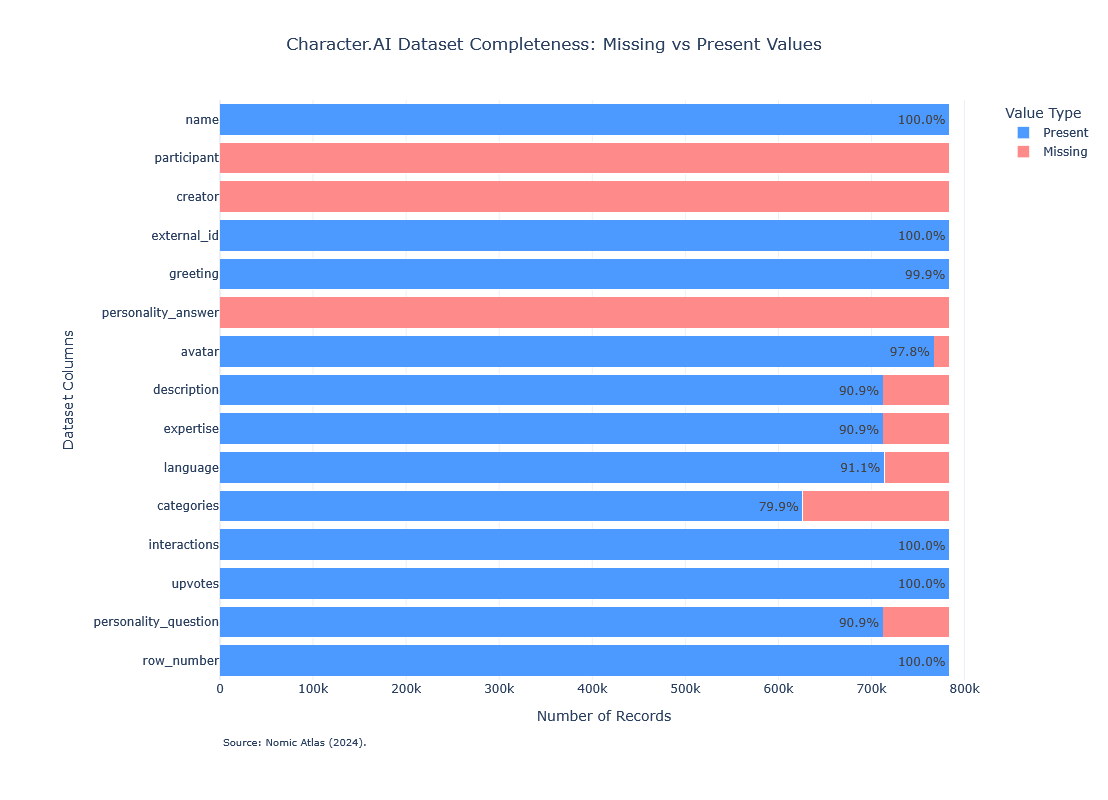

In [6]:
#0. bot figures path 


BOTS_FIGURES_PATH = PROJECT_ROOT / "reports" / "bots_figures"
BOTS_FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Interactive version
NULL_FIGURE_HTML = BOTS_FIGURES_PATH / "01_dataset_nullvalues.html"

# Thesis-ready static versions
NULL_FIGURE_PDF = BOTS_FIGURES_PATH / "01_dataset_nullvalues.pdf"
NULL_FIGURE_PNG = BOTS_FIGURES_PATH / "01_dataset_nullvalues.png"

# 1. copy dataset for calculating missingness
df_null = df.copy()

# 2.normalize 'null' values 
object_cols = df_null.select_dtypes(include=["object", "category"]).columns
null_values = {"None", "none", "NULL", "null", "NaN", "nan", "na", "n/a", ""}

for col in object_cols:
    df_null[col] = df_null[col].replace(list(null_values), np.nan)

# in category dtype normalize null
cat_cols = df_null.select_dtypes(include=["category"]).columns

for col in cat_cols:
    df_null[col] = df_null[col].astype("object").replace("[]", np.nan)

# precompute missingness 
total = len(df_null)

df_null_summary = pd.DataFrame({
    "Column": df_null.columns,
    "Missing": df_null.isna().sum().values,
    "Present": df_null.notna().sum().values
})

df_null_summary["Missing %"] = (
    df_null_summary["Missing"] / total * 100
).round(2)

display(HTML("<h3>3.4 Percentage of Missing Values in Character.AI Dataset (Source: Nomic Atlas)</h3>"))

#melt for plotly 
df_melt = df_null_summary.melt(
    id_vars="Column",
    value_vars=["Present", "Missing"],
    var_name="Value Type",
    value_name="Count"
)


# plot in plotly 
fig = px.bar(
    df_melt,
    y="Column",
    x="Count",
    color="Value Type",
    orientation="h",
    barmode="stack",
    text_auto=False,
    color_discrete_map={
        "Present": "#4C9AFF",
        "Missing": "#FF8A8A"
    },
    hover_data={
        "Column": True,
        "Count": True,
        "Value Type": True
    }
)

# show percent labels for non null in  each column
present_percentages = (
    df_null_summary["Present %"]
    if "Present %" in df_null_summary.columns
    else (df_null_summary["Present"] / total * 100).round(1)
)


for trace in fig.data:
    if trace.name == "Present":
        trace.text = [
            f"{p}%"
            for p in present_percentages
        ]
        trace.textposition = "inside"


fig.update_layout(
    title={
        "text": "Character.AI Dataset Completeness: Missing vs Present Values",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Number of Records",
    yaxis_title="Dataset Columns",
    height=max(800, len(df.columns) * 35),
    width=1100,
    template="plotly_white",
    legend_title="Value Type",
    margin=dict(
        l=220,
        r=50,
        t=100,
        b=120   
    ),
    annotations=[
        dict(
            text="Source: Nomic Atlas (2024).",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.12,   
            xanchor="left",
            showarrow=False,
            font=dict(size=10)
        )
    ]
)

# Save only if figure does not exist

if NULL_FIGURE_HTML.exists():

    print(f"Interactive figure already exists: {NULL_FIGURE_HTML}")

else:

    fig.write_html(
        NULL_FIGURE_HTML,
        include_plotlyjs="cdn"
    )

    print(f"Interactive figure saved: {NULL_FIGURE_HTML}")


# Save PDF for Overleaf / LaTeX
if NULL_FIGURE_PDF.exists():

    print(f"PDF figure already exists: {NULL_FIGURE_PDF}")

else:

    fig.write_image(
        NULL_FIGURE_PDF,
        format="pdf",
        width=1100,
        height=max(800, len(df.columns) * 35) + 100
    )

    print(f"PDF figure saved: {NULL_FIGURE_PDF}")


# Save high-resolution PNG backup
if NULL_FIGURE_PNG.exists():

    print(f"PNG figure already exists: {NULL_FIGURE_PNG}")

else:

    fig.write_image(
        NULL_FIGURE_PNG,
        format="png",
        scale=3
    )

    print(f"PNG figure saved: {NULL_FIGURE_PNG}")


# Display in notebook
fig.show()

<a id="4"></a>


# 4. BTS Character Bots Corpus


Creation of structured BTS bot corpora, including subsets of each boyband member and a combined dataset sorted by popularity (upvotes).

<a id="4.1"></a>


## 4.1 Filtering BTS Bots

Filtering English language bts character bots by identifying band member names in bot name, greeting and description and sorting them by popularity (upvotes)

In [7]:

def filter_bts_bots(df, members=None):
    """
    Filter CAI dataset for BTS-related English bots.
    Args:
    df (pd.DataFrame): Full Nomic CAI dataset.
    members (list of str, optional): BTS member names to filter.

    
    Returns:
        bts_df (pd.DataFrame) df of all bts bots 
        member_counts (dict) bot counts 
    """
    #list of member names
    if members is None:
        members = ["Jungkook", "Taehyung", "Jimin", "Yoongi", "Namjoon", "Hoseok", "Seokjin"]

    pattern = "|".join(members)

    # Mask: true for bts member English-language bots that can be recognized by bot names, description or greeting 

    mask = (
        df["name"].str.contains(pattern, case=False, na=False) |
        df["description"].str.contains(pattern, case=False, na=False) |
        df["greeting"].str.contains(pattern, case=False, na=False)
    ) & (df["language"].str.lower() == "english")

    bts_df = df[mask].copy()

    #sort them by upvotes to see popular ones first
    bts_df.sort_values("upvotes", ascending=False, inplace=True)

    #count bots per member
    member_counts = {
        m: bts_df["name"].str.contains(m, case=False, na=False).sum()
        for m in members
    }

    return bts_df, member_counts

In [8]:
bts_df, counts = filter_bts_bots(df)

<a id="4.2"></a>


## 4.2 Saving BTS Bots

Saving corpora for each member and a combined dataset in CSV 

In [9]:
def save_bts_bots(bts_df, members=None, save_dir=None):
    """
    Save BTS Character.AI bot subsets per member and a combined dataset.
    Existing files trigger an overwrite confirmation.
    Outputs are sorted by upvotes (descending).
    """

    # Project root
    PROJECT_ROOT = Path.cwd().parent

    # BTS members
    if members is None:
        members = [
            "Jungkook", "Taehyung", "Jimin",
            "Yoongi", "Namjoon", "Hoseok", "Seokjin"
        ]

    # Save directory
    if save_dir is None:
        save_dir = PROJECT_ROOT / "data" / "raw" / "bots"
    else:
        save_dir = Path(save_dir)

    save_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # Check existing files
    existing_files = list(save_dir.glob("*_bots_nomic.csv"))

    overwrite = False

    if existing_files:

        print("Existing BTS bot files found:")
        for f in existing_files:
            print(f" - {f.name}")

        while True:
            choice = input(
                "Overwrite existing BTS bot files? [y/n]: "
            ).strip().lower()

            if choice == "y":
                overwrite = True
                break

            elif choice == "n":
                overwrite = False
                break

            else:
                print("Please enter 'y' or 'n'.")


    # Build member subsets

    all_dfs = []

    for member in members:

        member_df = bts_df[
            bts_df["name"]
            .str.contains(
                member,
                case=False,
                na=False
            )
        ].copy()

        if member_df.empty:
            print(f"No bots found for {member}")
            continue

        member_df["member"] = member
        all_dfs.append(member_df)


    # Combine datasets

    if all_dfs:

        total_df = pd.concat(
            all_dfs,
            ignore_index=True
        )

        total_df = total_df.sort_values(
            "upvotes",
            ascending=False
        )

    else:

        total_df = pd.DataFrame()



    # Save combined dataset

    combined_path = save_dir / "bts_all_members_bots.csv"

    if combined_path.exists() and not overwrite:

        print(
            f"Skipped existing file: {combined_path.name}"
        )

    else:

        total_df.to_csv(
            combined_path,
            index=False
        )

        print(
            f"Saved combined dataset ({len(total_df)} rows) → {combined_path}"
        )


    # Save individual datasets

    for member in members:

        member_df = total_df[
            total_df["member"] == member
        ].copy()

        if member_df.empty:
            continue


        member_df = member_df.sort_values(
            "upvotes",
            ascending=False
        )

        file_path = save_dir / f"{member.lower()}_bots_nomic.csv"


        if file_path.exists() and not overwrite:

            print(
                f"Skipped existing file: {file_path.name}"
            )

        else:

            member_df.to_csv(
                file_path,
                index=False
            )

            print(
                f"Saved {len(member_df)} rows → {file_path}"
            )

In [10]:
save_bts_bots(bts_df)

Existing BTS bot files found:
 - hoseok_bots_nomic.csv
 - jimin_bots_nomic.csv
 - jungkook_bots_nomic.csv
 - namjoon_bots_nomic.csv
 - seokjin_bots_nomic.csv
 - taehyung_bots_nomic.csv
 - yoongi_bots_nomic.csv


Overwrite existing BTS bot files? [y/n]:  n


Skipped existing file: bts_all_members_bots.csv
Skipped existing file: jungkook_bots_nomic.csv
Skipped existing file: taehyung_bots_nomic.csv
Skipped existing file: jimin_bots_nomic.csv
Skipped existing file: yoongi_bots_nomic.csv
Skipped existing file: namjoon_bots_nomic.csv
Skipped existing file: hoseok_bots_nomic.csv
Skipped existing file: seokjin_bots_nomic.csv


<a id="4.3"></a>


## 4.3 Number of BTS Bots 

Visualization of bot counts per BTS member to understand bot distribution across the band members in the corpus. The visualizations are saved to be used as thesis figures. 

Skipped existing figure: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\02_bts_bots.html


Skipped existing HTML: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\03_bts_bots_freq.html
Skipped existing PDF: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\03_bts_bots_freq.pdf
Skipped existing PNG: E:\Jupyter_Programs\DH_Thesis\reports\bots_figures\03_bts_bots_freq.png


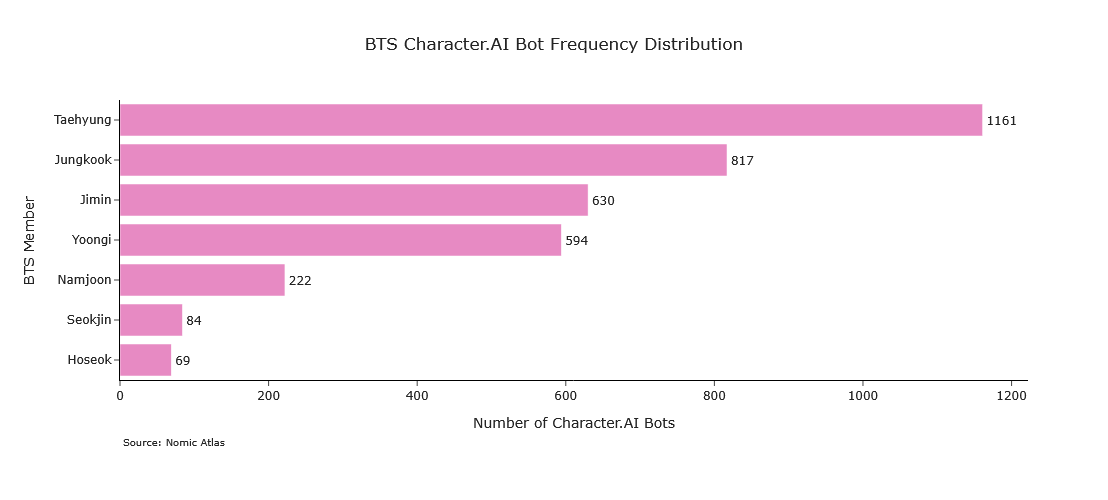

In [11]:
BOTS_FIGURES_PATH = PROJECT_ROOT / "reports" / "bots_figures"
BOTS_FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# Figure 02 - cards
BTS_CARDS_HTML = BOTS_FIGURES_PATH / "02_bts_bots.html"
BTS_CARDS_PDF = BOTS_FIGURES_PATH / "02_bts_bots.pdf"
BTS_CARDS_PNG = BOTS_FIGURES_PATH / "02_bts_bots.png"

# Figure 03 - frequency chart
BTS_FREQ_HTML = BOTS_FIGURES_PATH / "03_bts_bots_freq.html"
BTS_FREQ_PDF = BOTS_FIGURES_PATH / "03_bts_bots_freq.pdf"
BTS_FREQ_PNG = BOTS_FIGURES_PATH / "03_bts_bots_freq.png"



# FIGURE 02: BTS Bot Distribution Cards

colors = [
    "#FFADAD",
    "#FFD6A5",
    "#FDFFB6",
    "#CAFFBF",
    "#9BF6FF",
    "#A0C4FF",
    "#BDB2FF"
]


display(
    HTML(
        "<h3>4.3 BTS Character.AI Bot Distribution</h3>"
    )
)


cards_html = """
<html>
<head>

<style>

body {
    font-family: Arial, sans-serif;
}

.container {
    display:flex;
    gap:10px;
    flex-wrap:wrap;
}

.card {
    padding:15px;
    border-radius:10px;
    width:110px;
    text-align:center;
    box-shadow:2px 2px 6px rgba(0,0,0,0.15);
}

.name {
    font-size:16px;
    font-weight:bold;
    margin:5px;
}

.count {
    font-size:20px;
    font-weight:bold;
}

.label {
    font-size:12px;
    color:#555;
}

</style>

</head>

<body>

<div class="container">
"""


for i, (member, count) in enumerate(counts.items()):

    color = colors[i % len(colors)]

    cards_html += f"""

<div class="card" style="background:{color};">

<div class="name">
{member}
</div>

<div class="count">
{count}
</div>

<div class="label">
bots
</div>

</div>

"""


cards_html += """

</div>

</body>
</html>
"""


if BTS_CARDS_HTML.exists():

    print(
        f"Skipped existing figure: {BTS_CARDS_HTML}"
    )

else:

    BTS_CARDS_HTML.write_text(
        cards_html,
        encoding="utf-8"
    )

    print(
        f"Saved cards figure: {BTS_CARDS_HTML}"
    )


display(
    HTML(cards_html)
)




# FIGURE 03: Horizontal Frequency Bar Chart


freq_df = (
    pd.DataFrame(
        counts.items(),
        columns=[
            "Member",
            "Bot Count"
        ]
    )
    .sort_values(
        "Bot Count",
        ascending=True
    )
)



fig = px.bar(
    freq_df,
    x="Bot Count",
    y="Member",
    orientation="h",
    text="Bot Count",
    color_discrete_sequence=[
        "#e78ac3"
    ]
)


fig.update_traces(
    textposition="outside"
)


fig.update_layout(

    title={
        "text":
        "BTS Character.AI Bot Frequency Distribution",
        "x":0.5,
        "xanchor":"center"
    },

    xaxis_title=
    "Number of Character.AI Bots",

    yaxis_title=
    "BTS Member",

    template="simple_white",

    height=500,

    width=900,

    showlegend=False,

    margin=dict(
        l=120,
        r=80,
        t=100,
        b=120
    ),

    annotations=[
        dict(
            text=
            "Source: Nomic Atlas",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.25,
            showarrow=False,
            xanchor="left",
            font=dict(size=10)
        )
    ]
)

fig.update_layout(
    xaxis=dict(
        showgrid=False,
        showline=True,
        linecolor="black"
    ),
    yaxis=dict(
        showgrid=False,
        showline=True,
        linecolor="black"
    )
)



# Save Figure 03


if BTS_FREQ_HTML.exists():

    print(
        f"Skipped existing HTML: {BTS_FREQ_HTML}"
    )

else:

    fig.write_html(
        BTS_FREQ_HTML,
        include_plotlyjs="cdn"
    )

    print(
        f"Saved HTML: {BTS_FREQ_HTML}"
    )



if BTS_FREQ_PDF.exists():

    print(
        f"Skipped existing PDF: {BTS_FREQ_PDF}"
    )

else:

    fig.write_image(
        BTS_FREQ_PDF,
        format="pdf"
    )

    print(
        f"Saved PDF: {BTS_FREQ_PDF}"
    )



if BTS_FREQ_PNG.exists():

    print(
        f"Skipped existing PNG: {BTS_FREQ_PNG}"
    )

else:

    fig.write_image(
        BTS_FREQ_PNG,
        format="png",
        scale=3
    )

    print(
        f"Saved PNG: {BTS_FREQ_PNG}"
    )


display(
    HTML(
        "<h3> BTS Character.AI Bot Frequency</h3>"
    )
)

fig.show()

<a id="4.4"></a>


## 4.4 Sample Records Generated Randomly of BTS Bots by High Upvotes

Random selection of high-upvote bots to inspect high-quality or popular Character.AI entries across BTS members. These random samples are saved for thesis figures.

In [13]:
# Filter and sample dataframe
high_upvote_df = bts_df[bts_df["upvotes"] >= 100]

sample_df = high_upvote_df.sample(5, random_state=577)

display(HTML("<h3>4.4 Five Sample Records Generated Randomly</h3>"))

# List to collect HTML snippets for the combined HTML file
html_cards = []

# Display & save each sample
for sample_number, (_, row) in enumerate(sample_df.iterrows(), start=1):

    # 1. Generate notebook HTML representation
    card_html = f"""
    <div style='
        padding:15px;
        border:1px solid #ccc;
        border-radius:10px;
        margin-bottom:15px;
        font-family:Arial;
    '>
        <h4>{sample_number}. {row['name']}</h4>
        <b>Greeting:</b><br>
        {row['greeting']}<br><br>
        <b>Description:</b><br>
        {row['description']}<br><br>
        <b>Expertise:</b><br>
        {row['expertise']}<br><br>
        <b>Upvotes:</b> {row['upvotes']}<br>
        <b>Language:</b> {row['language']}<br>
        <b>Row Number:</b> {row['row_number']}
    </div>
    """

    # Display in Jupyter Notebook
    display(HTML(card_html))

    # Append to our HTML collector list
    html_cards.append(card_html)

    # 2. File paths for static figures
    pdf_path = BOTS_FIGURES_PATH / f"04_bot_sample_{sample_number:02d}.pdf"
    png_path = BOTS_FIGURES_PATH / f"04_bot_sample_{sample_number:02d}.png"

    # Create static card figure
    text = f"""
<b>{row['name']}</b><br><br>

<b>Greeting:</b><br>{str(row['greeting'])[:600]}<br><br>

<b>Description:</b><br>{str(row['description'])[:500]}<br><br>

<b>Expertise:</b><br>{str(row['expertise'])[:300]}<br><br>

<b>Upvotes:</b> {row['upvotes']}
&nbsp;&nbsp; 
<b>Language:</b> {row['language']}
<br>
<b>Row Number:</b> {row['row_number']}
"""

    fig = go.Figure()

    fig.add_annotation(
        x=0.5,
        y=0.5,
        text=text,
        showarrow=False,
        align="left",
        bordercolor="black",
        borderwidth=1,
        borderpad=20,
        bgcolor="white",
        font=dict(size=12),
    )

    fig.update_layout(
        width=1000,
        height=700,
        template="plotly_white",
        xaxis=dict(visible=False, showgrid=False),
        yaxis=dict(visible=False, showgrid=False),
        margin=dict(l=50, r=50, t=50, b=50),
        annotations=[
            dict(
                text="Source: Nomic Atlas Character.AI dataset.",
                xref="paper",
                yref="paper",
                x=0,
                y=-0.05,
                showarrow=False,
                font=dict(size=10),
            )
        ],
    )

    # Save PDF
    if pdf_path.exists():
        print(f"Skipped existing: {pdf_path.name}")
    else:
        fig.write_image(pdf_path, format="pdf")
        print(f"Saved: {pdf_path.name}")

    # Save PNG
    if png_path.exists():
        print(f"Skipped existing: {png_path.name}")
    else:
        fig.write_image(png_path, format="png", scale=3)
        print(f"Saved: {png_path.name}")


# Save all sample cards together into a single HTML file
combined_html_path = BOTS_FIGURES_PATH / "04_bot_samples.html"

# Check if HTML already exists before writing
if combined_html_path.exists():
    print(f"Skipped existing: {combined_html_path.name}")
else:
    full_html_content = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Bot Sample Records</title>
</head>
<body style="font-family: Arial, sans-serif; margin: 20px;">
    <h2>4.4 Five Sample Records Generated Randomly</h2>
    {''.join(html_cards)}
</body>
</html>
"""
    with open(combined_html_path, "w", encoding="utf-8") as f:
        f.write(full_html_content)

    print(f"Saved: {combined_html_path.name}")

Skipped existing: 04_bot_sample_01.pdf
Skipped existing: 04_bot_sample_01.png


Skipped existing: 04_bot_sample_02.pdf
Skipped existing: 04_bot_sample_02.png


Skipped existing: 04_bot_sample_03.pdf
Skipped existing: 04_bot_sample_03.png


Skipped existing: 04_bot_sample_04.pdf
Skipped existing: 04_bot_sample_04.png


Skipped existing: 04_bot_sample_05.pdf
Skipped existing: 04_bot_sample_05.png
Saved: 04_bot_samples.html
